# 🎬 MovieLens ml-32m — Recommendation Model Pipeline

End-to-end workflow for exploring MovieLens data, preparing train/validation/test splits, training recommendation baselines and models, and saving deployable artifacts.

## 0. Configuration

Define shared imports, plotting defaults, and the dataset root used throughout the notebook.

In [23]:
import os
os.environ.setdefault("MPLCONFIGDIR", ".matplotlib-cache")
%matplotlib inline
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import scipy.sparse as sp
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

BASE = Path("ml-32m")
assert BASE.exists(), "ml-32m didn't exist -> run from the project root"
print("Data directory:", BASE.resolve())

Data directory: /Users/mskayacioglu/Documents/projects/MovieLens/ml-32m


## 0.1. Environment info

Record the runtime, package versions, device support, and thread settings for reproducibility.

In [24]:
import importlib.metadata as importlib_metadata
import platform, sys
import torch

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print("Processor:", platform.processor())

print("\nPackages:")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("torch:", torch.__version__)
print("implicit:", importlib_metadata.version("implicit"))

print("\nTorch devices:")
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())
print("Selected device:", device if "device" in globals() else "not defined yet")

print("\nThreads:")
print("OPENBLAS_NUM_THREADS:", os.environ.get("OPENBLAS_NUM_THREADS"))
print("torch num threads:", torch.get_num_threads())

Python: 3.14.6 (main, Jun 10 2026, 10:03:53) [Clang 21.0.0 (clang-2100.0.123.102)]
Executable: /Users/mskayacioglu/Documents/projects/MovieLens/.venv/bin/python
Platform: macOS-26.5.1-arm64-arm-64bit-Mach-O
Processor: arm

Packages:
numpy: 2.5.0
pandas: 3.0.3
scipy: 1.18.0
matplotlib: 3.11.0
torch: 2.12.1
implicit: 0.7.3

Torch devices:
CUDA available: False
MPS available: True
Selected device: mps

Threads:
OPENBLAS_NUM_THREADS: None
torch num threads: 4


---

# 1. Exploratory Data Analysis

Profile dataset size, rating behavior, temporal patterns, genres, and tags before modeling.

## 1.1. Upload the data

Load ratings, movie metadata, links, and tags with memory-aware dtypes.

In [25]:
%%time
ratings = pd.read_csv(BASE/"ratings.csv",
    dtype={"userId":"int32","movieId":"int32","rating":"float32","timestamp":"int64"})
movies = pd.read_csv(BASE/"movies.csv")
links  = pd.read_csv(BASE/"links.csv")
tags   = pd.read_csv(BASE/"tags.csv")
print("ratings:", ratings.shape, "| memory MB:",
      round(ratings.memory_usage(deep=True).sum()/1e6, 1))
ratings.head()

ratings: (32000204, 4) | memory MB: 640.0
CPU times: user 5.57 s, sys: 511 ms, total: 6.08 s
Wall time: 6.29 s


,userId,movieId,rating,timestamp
0,1,17,4.000,944249077
1,1,25,1.000,944250228
2,1,29,2.000,943230976
3,1,30,5.000,944249077
4,1,32,5.000,943228858


## 1.2. Basic data and missing values

Check core counts, catalog coverage, missing values, and genre completeness.

In [26]:
n_users        = ratings.userId.nunique()
n_movies_rated = ratings.movieId.nunique()
n_ratings      = len(ratings)

print(f"User                            : {n_users:,}")
print(f"Rated movies                    : {n_movies_rated:,}  (movies.csv has {len(movies):,} movies)")
print(f"Total ratings                   : {n_ratings:,}")
print(f"Total tags                      : {len(tags):,}")
print(f"Average ratings/user.           : {n_ratings/n_users:.1f}")
print()
print("Missing values (ratings)        :", ratings.isna().sum().to_dict())
print("'(no genres listed)' movie count:", int((movies.genres=='(no genres listed)').sum()))

User                            : 200,948
Rated movies                    : 84,432  (movies.csv has 87,585 movies)
Total ratings                   : 32,000,204
Total tags                      : 2,000,072
Average ratings/user.           : 159.2

Missing values (ratings)        : {'userId': 0, 'movieId': 0, 'rating': 0, 'timestamp': 0}
'(no genres listed)' movie count: 7080


## 1.3. Rating distribution

Inspect rating scale usage to understand class balance and central tendency.

,count,pct
rating,,
0.500,525132,1.640
1.000,946675,2.960
1.500,531063,1.660
2.000,2028622,6.340
2.500,1685386,5.270
3.000,6054990,18.920
3.500,4290105,13.410
4.000,8367654,26.150
4.500,2974000,9.290


mean=3.540  median=3.5  std=1.059


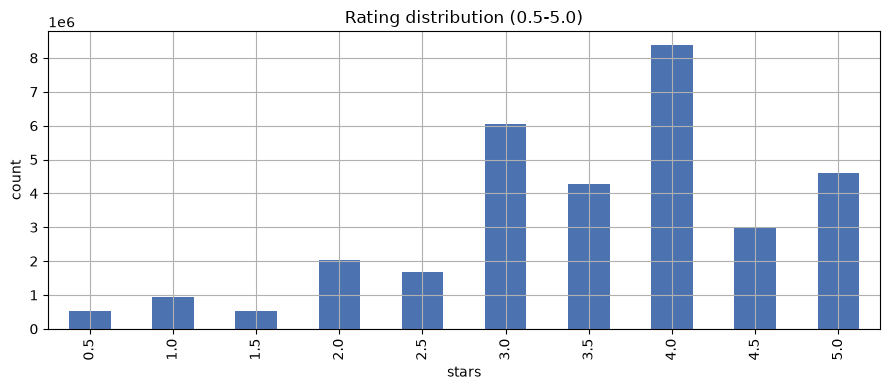

In [27]:
rd = ratings.rating.value_counts().sort_index()
display(rd.to_frame("count").assign(pct=lambda d: (d["count"] / n_ratings * 100).round(2)))
print(f"mean={ratings.rating.mean():.3f}  median={ratings.rating.median()}  std={ratings.rating.std():.3f}")

ax = rd.plot(kind="bar", color="#4C72B0")
ax.set_title("Rating distribution (0.5-5.0)")
ax.set_xlabel("stars"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

## 1.4. Ratings per user

Measure user activity to reveal heavy users and sparse user histories.

,ratings/user
count,"200,948.000"
mean,159.200
std,282.000
min,20.000
25%,36.000
50%,73.000
75%,167.000
90%,364.000
99%,"1,290.000"
max,"33,332.000"


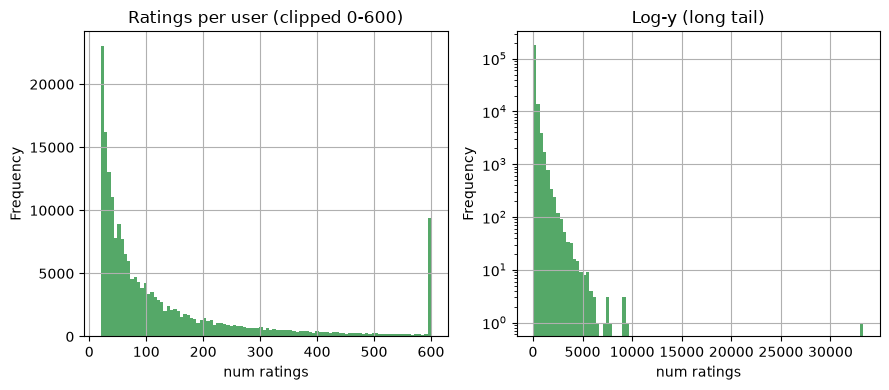

In [28]:
rpu = ratings.groupby("userId").size()
display(rpu.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_frame("ratings/user"))

fig, ax = plt.subplots(1, 2)
rpu.clip(upper=600).plot(kind="hist", bins=100, ax=ax[0], color="#55A868")
ax[0].set_title("Ratings per user (clipped 0-600)"); ax[0].set_xlabel("num ratings")
rpu.plot(kind="hist", bins=100, logy=True, ax=ax[1], color="#55A868")
ax[1].set_title("Log-y (long tail)"); ax[1].set_xlabel("num ratings")
plt.tight_layout(); plt.show()

## 1.5. Ratings per movie (long tail)

Measure item activity and expose the popularity long tail that affects recommendations.

,ratings/movie
count,"84,432.000"
mean,379.000
std,"2,592.400"
min,1.000
25%,2.000
50%,5.000
75%,25.000
90%,248.900
99%,"9,263.100"
max,"102,929.000"


movies with 1 rating: 18607 | <=5 ratings: 44027
Top 1% movies (844) hold 54.8% of all ratings


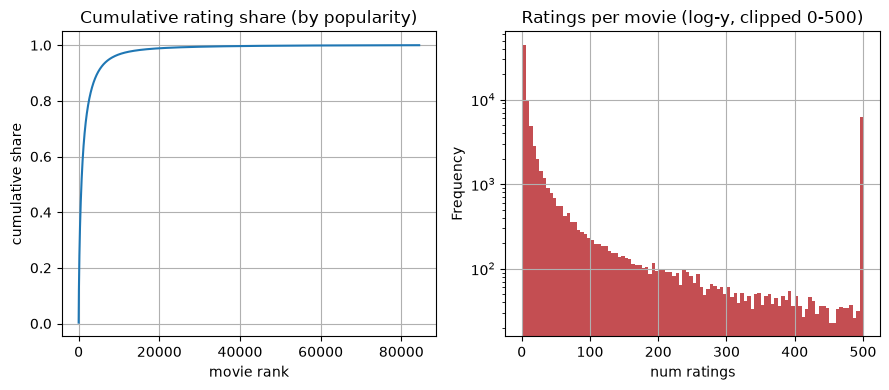

In [29]:
rpm = ratings.groupby("movieId").size()
display(rpm.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_frame("ratings/movie"))
print("movies with 1 rating:", int((rpm == 1).sum()), "| <=5 ratings:", int((rpm <= 5).sum()))

rpm_sorted = rpm.sort_values(ascending=False).reset_index(drop=True)
cum = rpm_sorted.cumsum() / rpm_sorted.sum()
top1 = max(1, int(len(rpm_sorted) * 0.01))
print(f"Top 1% movies ({top1}) hold {rpm_sorted.iloc[:top1].sum()/n_ratings*100:.1f}% of all ratings")

fig, ax = plt.subplots(1, 2)
ax[0].plot(cum.values)
ax[0].set_title("Cumulative rating share (by popularity)")
ax[0].set_xlabel("movie rank"); ax[0].set_ylabel("cumulative share")
rpm.clip(upper=500).plot(kind="hist", bins=100, logy=True, ax=ax[1], color="#C44E52")
ax[1].set_title("Ratings per movie (log-y, clipped 0-500)"); ax[1].set_xlabel("num ratings")
plt.tight_layout(); plt.show()

## 1.6. Sparsity

Estimate how much of the user-item matrix is observed versus empty.

In [30]:
density = n_ratings / (n_users * n_movies_rated)
print(f"Matrix : {n_users:,} users x {n_movies_rated:,} movies = {n_users * n_movies_rated:,} cells")
print(f"Filled : {n_ratings:,}")
print(f"Density  = {density * 100:.4f}%   (sparsity = {(1 - density) * 100:.4f}%)")

Matrix : 200,948 users x 84,432 movies = 16,966,441,536 cells
Filled : 32,000,204
Density  = 0.1886%   (sparsity = 99.8114%)


## 1.7. Temporal analysis

Review rating timestamps to understand time coverage and activity changes.

Range: 1995 - 2023


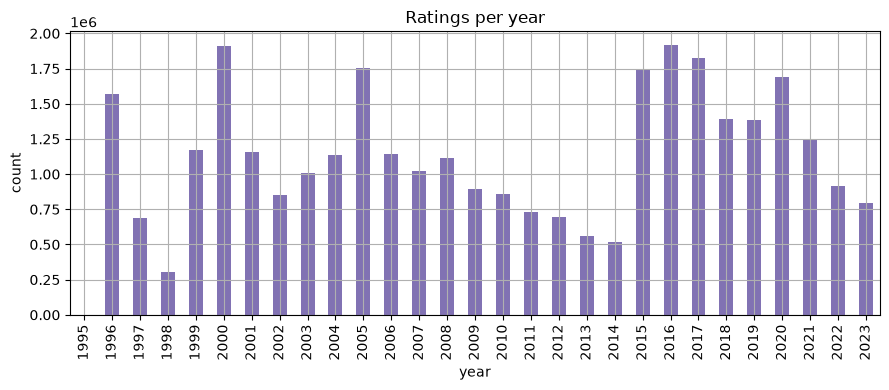

In [31]:
dt = pd.to_datetime(ratings.timestamp, unit="s")
by_year = dt.dt.year.value_counts().sort_index()
print("Range:", int(by_year.index.min()), "-", int(by_year.index.max()))

by_year.plot(kind="bar", color="#8172B3")
plt.title("Ratings per year"); plt.xlabel("year"); plt.ylabel("count")
plt.tight_layout(); plt.show()

## 1.8. Genres

Explode movie genres to compare catalog coverage and average ratings by genre.

,mean,count
genre,,
Film-Noir,3.916,304710
War,3.792,1594110
Crime,3.692,5373051
Documentary,3.691,427353
Drama,3.682,13973271
Mystery,3.673,2615322
Animation,3.615,2214562
Western,3.600,596654
IMAX,3.593,1494179


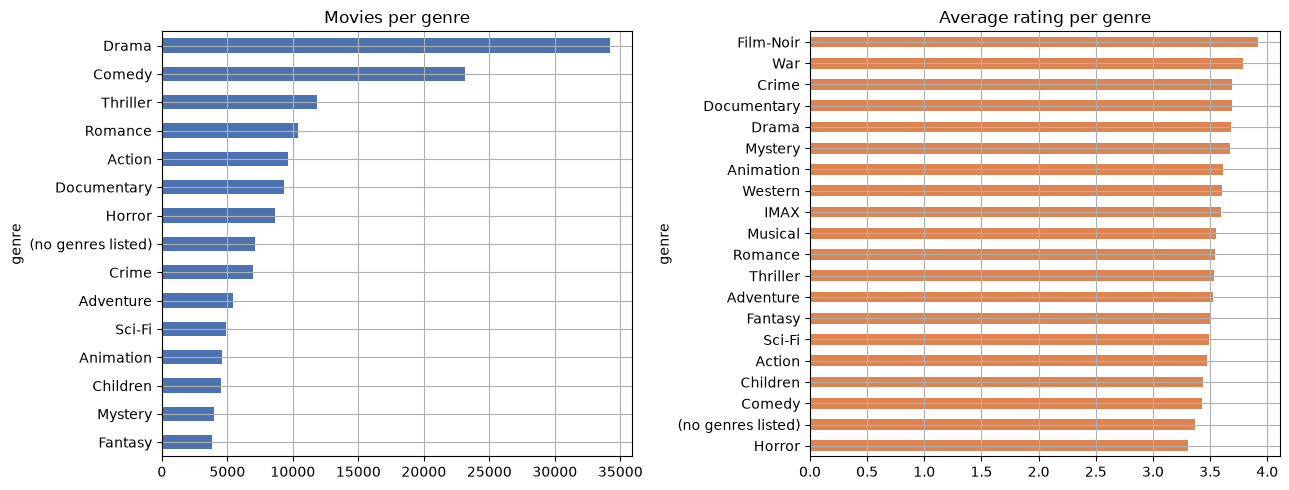

In [32]:
g = movies.assign(genre=movies.genres.str.split("|")).explode("genre")
gcount = g.genre.value_counts()

mg = ratings.merge(g[["movieId", "genre"]], on="movieId")
gavg = mg.groupby("genre").rating.agg(["mean", "count"]).sort_values("mean", ascending=False)
display(gavg.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
gcount.head(15).plot(kind="barh", ax=ax[0], color="#4C72B0"); ax[0].invert_yaxis()
ax[0].set_title("Movies per genre")
gavg["mean"].plot(kind="barh", ax=ax[1], color="#DD8452"); ax[1].invert_yaxis()
ax[1].set_title("Average rating per genre")
plt.tight_layout(); plt.show()

## 1.9. Popularity vs quality (top movies)

Separate highly rated movies from merely frequent movies by applying a vote threshold.

In [33]:
MIN_CT = 1000
stats = ratings.groupby("movieId").rating.agg(["mean", "count"])
top = (stats[stats["count"] >= MIN_CT]
       .sort_values("mean", ascending=False)
       .head(15)
       .merge(movies[["movieId", "title"]], on="movieId"))
print(f"Highest rated movies (min {MIN_CT} votes):")
top[["title", "mean", "count"]]

Highest rated movies (min 1000 votes):


,title,mean,count
0,Planet Earth II (2016),4.447,1956
1,Planet Earth (2006),4.444,2948
2,Band of Brothers (2001),4.427,2811
3,"Shawshank Redemption, The (1994)",4.405,102929
4,"Godfather, The (1972)",4.317,66440
5,Parasite (2019),4.312,11670
6,Blue Planet II (2017),4.300,1163
7,Twin Peaks (1989),4.299,1140
8,12 Angry Men (1957),4.265,21863
9,"Usual Suspects, The (1995)",4.265,67750


## 1.10. Tags overview

Summarize user-generated tags as optional semantic signals for future models.

In [34]:
print("Total tags:", len(tags), "| unique tags:", tags.tag.nunique(),
      "| users who tagged:", tags.userId.nunique())
print("\nTop 15 tags:")
tags.tag.value_counts().head(15)

Total tags: 2000072 | unique tags: 140979 | users who tagged: 15848

Top 15 tags:


tag
sci-fi                10996
atmospheric            9589
action                 8473
comedy                 8139
funny                  7467
surreal                7231
visually appealing     7090
based on a book        6617
twist ending           6521
dark comedy            6053
thought-provoking      6000
dystopia               5646
violence               5389
cinematography         5277
romance                5271
Name: count, dtype: int64

---

# 2. Preprocessing & Train/Val/Test Split

Clean IDs, control noisy items, split chronologically per user, and build sparse matrices.

## 2.1. Minimum-interaction filter

Remove very rare movies to reduce noise and keep the matrix tractable.

In [35]:
MIN_MOVIE_RATINGS = 5   # drop movies with fewer than this many ratings (noisy / cold)

movie_counts = ratings.movieId.value_counts()
keep_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index

before = len(ratings)
ratings_f = ratings[ratings.movieId.isin(keep_movies)].copy()

print(f"Movies : {ratings.movieId.nunique():,}          -> {ratings_f.movieId.nunique():,}")
print(f"Ratings: {before:,}      -> {len(ratings_f):,}  ({len(ratings_f)/before*100:.2f}% kept)")
print(f"Users  : {ratings.userId.nunique():,}         -> {ratings_f.userId.nunique():,}")

Movies : 84,432          -> 43,884
Ratings: 32,000,204      -> 31,921,467  (99.75% kept)
Users  : 200,948         -> 200,948


## 2.2. Reindex to 0-based indices

Map MovieLens IDs to compact integer indices required by sparse matrices and embeddings.

In [36]:
user_cat  = ratings_f.userId.astype("category")
movie_cat = ratings_f.movieId.astype("category")

ratings_f["user_idx"]  = user_cat.cat.codes.astype("int32")
ratings_f["movie_idx"] = movie_cat.cat.codes.astype("int32")

# index -> original id  (to map predictions back to real users/movies later)
user_ids  = user_cat.cat.categories.to_numpy()
movie_ids = movie_cat.cat.categories.to_numpy()

n_users  = len(user_ids)
n_movies = len(movie_ids)

print(f"users : {n_users:,}  | user_idx  {ratings_f.user_idx.min()}..{ratings_f.user_idx.max()}")
print(f"movies: {n_movies:,}   | movie_idx {ratings_f.movie_idx.min()}..{ratings_f.movie_idx.max()}")
ratings_f[["userId", "user_idx", "movieId", "movie_idx", "rating"]].head()

users : 200,948  | user_idx  0..200947
movies: 43,884   | movie_idx 0..43883


,userId,user_idx,movieId,movie_idx,rating
0,1,0,17,16,4.000
1,1,0,25,24,1.000
2,1,0,29,28,2.000
3,1,0,30,29,5.000
4,1,0,32,31,5.000


## 2.3. Time-based split var

Create per-user chronological splits to reduce leakage from future ratings.

In [37]:
TRAIN_FRAC, VAL_FRAC = 0.8, 0.1   # per-user, chronological; the rest -> test

ratings_f = ratings_f.sort_values(["user_idx", "timestamp"], kind="stable").reset_index(drop=True)

grp  = ratings_f.groupby("user_idx", sort=False)
frac = grp.cumcount() / grp["user_idx"].transform("size")   # 0..1 time position within each user

ratings_f["split"] = np.select(
    [frac < TRAIN_FRAC, frac < TRAIN_FRAC + VAL_FRAC],
    ["train", "val"],
    default="test",
)

counts = ratings_f["split"].value_counts()
print(counts)
print((counts / len(ratings_f) * 100).round(2).astype(str) + " %")

split
train    25614481
val       3200365
test      3106621
Name: count, dtype: int64
split
train    80.24 %
val      10.03 %
test      9.73 %
Name: count, dtype: str


## 2.4. Sparse (CSR) matrices

Materialize the training interactions as a CSR matrix for efficient matrix operations.

In [38]:
from scipy.sparse import csr_matrix

train = ratings_f[ratings_f.split == "train"]
val   = ratings_f[ratings_f.split == "val"]
test  = ratings_f[ratings_f.split == "test"]

def build_csr(df, n_users, n_movies):
    return csr_matrix(
        (df["rating"].to_numpy(dtype="float32"),
         (df["user_idx"].to_numpy(), df["movie_idx"].to_numpy())),
        shape=(n_users, n_movies),
    )

R_train = build_csr(train, n_users, n_movies)   # users x movies, values = rating

print("splits  -> train:", f"{len(train):,}", "| val:", f"{len(val):,}", "| test:", f"{len(test):,}")
print("R_train :", R_train.shape, "| nnz:", f"{R_train.nnz:,}",
      "| density: %.4f%%" % (R_train.nnz / (n_users * n_movies) * 100))

splits  -> train: 25,614,481 | val: 3,200,365 | test: 3,106,621
R_train : (200948, 43884) | nnz: 25,614,481 | density: 0.2905%


---

# 3. Baselines

Build simple reference models so later methods have meaningful comparison points.

## 3.1. Global mean (RMSE / MAE)

Predict the train-set mean for every rating as the lowest-complexity baseline.

In [39]:
mu = train["rating"].mean()   # TRAIN only -> no leakage
print(f"global mean (mu) = {mu:.4f}")

def rmse(pred, true):
    pred = np.asarray(pred, dtype="float64"); true = np.asarray(true, dtype="float64")
    return np.sqrt(np.mean((pred - true) ** 2))

def mae(pred, true):
    pred = np.asarray(pred, dtype="float64"); true = np.asarray(true, dtype="float64")
    return np.mean(np.abs(pred - true))

for name, df in [("val", val), ("test", test)]:
    p = np.full(len(df), mu)
    print(f"[global-mean] {name}: RMSE={rmse(p, df['rating']):.4f}  MAE={mae(p, df['rating']):.4f}")

global mean (mu) = 3.5587
[global-mean] val: RMSE=1.0573  MAE=0.8272
[global-mean] test: RMSE=1.0571  MAE=0.8267


## 3.2. Bias baseline

Add user and item effects to capture systematic rating tendencies before learning latent factors.

Prediction:

$$\hat{r}_{ui} = \mu + b_u + b_i$$

Biases are estimated from the **training set** with regularization:

$$
b_i = \frac{\sum_{u \in R(i)} (r_{ui} - \mu)}{\lambda_i + |R(i)|}
\qquad
b_u = \frac{\sum_{i \in R(u)} (r_{ui} - \mu - b_i)}{\lambda_u + |R(u)|}
$$

- $\mu$ — global mean rating (train only)
- $b_i$ — item bias: how much movie $i$ deviates from $\mu$
- $b_u$ — user bias: user $u$'s tendency after removing $\mu$ and $b_i$
- $R(i),\, R(u)$ — set of ratings for item $i$ / by user $u$
- $\lambda_i,\, \lambda_u$ — regularization; shrinks bias for rarely-rated items/users toward $0$

In [40]:
LAMBDA_I, LAMBDA_U = 10.0, 10.0   # regularization (shrinks bias for rarely-rated items/users)

# item bias: b_i = sum(r - mu) / (lambda + count)
dev = train.assign(dev=train["rating"] - mu)
gi  = dev.groupby("movie_idx")["dev"]
b_i = (gi.sum() / (gi.count() + LAMBDA_I)).reindex(range(n_movies), fill_value=0.0).to_numpy()

# user bias: b_u = sum(r - mu - b_i) / (lambda + count)
dev2 = train.assign(dev=train["rating"] - mu - b_i[train["movie_idx"].to_numpy()])
gu   = dev2.groupby("user_idx")["dev"]
b_u  = (gu.sum() / (gu.count() + LAMBDA_U)).reindex(range(n_users), fill_value=0.0).to_numpy()

def predict_bias(df):
    p = mu + b_u[df["user_idx"].to_numpy()] + b_i[df["movie_idx"].to_numpy()]
    return np.clip(p, 0.5, 5.0)

for name, df in [("val ", val), ("test", test)]:
    p = predict_bias(df)
    print(f"[bias] {name}: RMSE={rmse(p, df['rating']):.4f}  MAE={mae(p, df['rating']):.4f}")

[bias] val : RMSE=0.8633  MAE=0.6537
[bias] test: RMSE=0.8763  MAE=0.6631


## 3.3. Top-N evaluation setup (Recall@K, NDCG@K)

Define the shared ranking protocol and held-out relevance target for Top-N evaluation.

In [41]:
K_EVAL      = 10      # top-K
REL         = 4.0     # a held-out item counts as "relevant" if rated >= REL
N_EVAL_USERS = 10_000 # sample of users for ranking eval (keeps it fast; reused for MF/ALS)
EMPTY = frozenset()

# ground truth (from TEST) + items to exclude (seen in TRAIN)  -- built once, reused
test_rel   = test[test.rating >= REL].groupby("user_idx")["movie_idx"].apply(set)
train_seen = train.groupby("user_idx")["movie_idx"].apply(set)   # ~20-40 s, big
print(f"users with >=1 relevant test item: {len(test_rel):,}")

def evaluate_ranking(rank_fn, rel=test_rel, seen=train_seen, K=K_EVAL,
                     n_users=N_EVAL_USERS, seed=0):
    users = rel.index.to_numpy()
    rng = np.random.default_rng(seed)
    if n_users and len(users) > n_users:
        users = rng.choice(users, n_users, replace=False)
    recalls, ndcgs = [], []
    discount = 1.0 / np.log2(np.arange(2, K + 2))          # positional discount
    for u in users:
        gt   = rel[u]
        topk = rank_fn(u, seen.get(u, EMPTY), K)           # array of movie_idx, seen excluded
        hits = np.fromiter((it in gt for it in topk), dtype=float, count=len(topk))
        recalls.append(hits.sum() / len(gt))
        idcg = discount[:min(len(gt), K)].sum()
        ndcgs.append((hits * discount[:len(hits)]).sum() / idcg if idcg > 0 else 0.0)
    return {f"Recall@{K}": np.mean(recalls), f"NDCG@{K}": np.mean(ndcgs), "users": len(users)}

users with >=1 relevant test item: 187,278


## 3.4. Popularity baseline

Rank unseen movies by training popularity to establish a strong non-personalized recommender.

In [42]:
# popularity = number of TRAIN ratings per movie (most-rated first)
pop_count = np.zeros(n_movies, dtype="int64")
vc = train["movie_idx"].value_counts()
pop_count[vc.index.to_numpy()] = vc.to_numpy()
pop_order = np.argsort(-pop_count).tolist()          # movie_idx, popular -> rare

def rank_pop(u, seen, K):
    out = []
    for it in pop_order:
        if it not in seen:
            out.append(it)
            if len(out) == K:
                break
    return out

print("[popularity]", evaluate_ranking(rank_pop))

[popularity] {'Recall@10': np.float64(0.048898641209417885), 'NDCG@10': np.float64(0.043027065028018396), 'users': 10000}


---

# 4. Matrix Factorization

Train an explicit-feedback latent factor model for rating prediction and compare ranking behavior.

## 4.1. Model definition

Learn user and movie embeddings from explicit ratings while retaining the bias terms from the baseline.

Prediction = bias baseline + latent factor interaction:

$$\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u^\top \mathbf{q}_i$$

- $\mathbf{p}_u \in \mathbb{R}^f$ — user latent factors, $\ \mathbf{q}_i \in \mathbb{R}^f$ — movie latent factors
- $f$ — number of latent factors (embedding dim)

Trained by minimizing regularized squared error:

$$\min \sum_{(u,i)} (r_{ui} - \hat{r}_{ui})^2 + \lambda\big(\lVert\mathbf{p}_u\rVert^2 + \lVert\mathbf{q}_i\rVert^2 + b_u^2 + b_i^2\big)$$

In [43]:
nn = torch.nn

class MF(nn.Module):
    def __init__(self, n_users, n_movies, n_factors=64, mu=0.0):
        super().__init__()
        self.user_factors  = nn.Embedding(n_users,  n_factors)
        self.movie_factors = nn.Embedding(n_movies, n_factors)
        self.user_bias     = nn.Embedding(n_users,  1)
        self.movie_bias    = nn.Embedding(n_movies, 1)
        self.register_buffer("mu", torch.tensor(float(mu)))   # fixed global mean

        nn.init.normal_(self.user_factors.weight,  std=0.05)
        nn.init.normal_(self.movie_factors.weight, std=0.05)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, u, i):
        dot = (self.user_factors(u) * self.movie_factors(i)).sum(dim=1)
        bu  = self.user_bias(u).squeeze(1)
        bi  = self.movie_bias(i).squeeze(1)
        return self.mu + bu + bi + dot

print("MF defined | factors default = 64")

MF defined | factors default = 64


## 4.2. Training data & device

Convert split data into PyTorch tensors and select the best available compute device.

In [44]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("device:", device)

def to_tensors(df):
    u = torch.tensor(df["user_idx"].to_numpy(),             dtype=torch.long)
    i = torch.tensor(df["movie_idx"].to_numpy(),            dtype=torch.long)
    r = torch.tensor(df["rating"].to_numpy(dtype="float32"), dtype=torch.float32)
    return u, i, r

u_train, i_train, r_train = to_tensors(train)
u_val,   i_val,   r_val   = to_tensors(val)
u_test,  i_test,  r_test  = to_tensors(test)

print("train:", u_train.shape[0], "| val:", u_val.shape[0], "| test:", u_test.shape[0])
print("dtypes -> idx:", u_train.dtype, "| rating:", r_train.dtype)

device: mps
train: 25614481 | val: 3200365 | test: 3106621
dtypes -> idx: torch.int64 | rating: torch.float32


## 4.3. Training loop

Optimize the model with minibatches, factor regularization, validation tracking, and early stopping.

In [45]:
@torch.no_grad()
def predict_rmse(model, u, i, r, bs=200_000):
    model.eval()
    se, n = 0.0, 0
    for s in range(0, len(u), bs):
        pred = model(u[s:s+bs].to(device), i[s:s+bs].to(device)).clamp(0.5, 5.0).cpu()
        se += ((pred - r[s:s+bs]) ** 2).sum().item()
        n  += len(pred)
    return (se / n) ** 0.5

# --- hyperparameters ---
N_FACTORS, LR_FACTORS, LR_BIAS = 128, 5e-3, 5e-4   # biases start at closed-form -> tiny LR
LAMBDA_F = 0.02        # batch-local L2 on active factor rows (the lambda in 4.1)
BATCH, EPOCHS, PATIENCE = 16_384, 20, 3

torch.manual_seed(0)
model = MF(n_users, n_movies, n_factors=N_FACTORS, mu=mu).to(device)

# warm-start b_u / b_i from the closed-form baseline (3.2) -> start exactly at the baseline
with torch.no_grad():
    model.user_bias.weight.copy_(torch.tensor(b_u, dtype=torch.float32).unsqueeze(1))
    model.movie_bias.weight.copy_(torch.tensor(b_i, dtype=torch.float32).unsqueeze(1))

# weight_decay=0 -> regularization lives in the loss, only for rows in the batch
opt = torch.optim.Adam([
    {"params": [model.user_factors.weight, model.movie_factors.weight], "lr": LR_FACTORS},
    {"params": [model.user_bias.weight, model.movie_bias.weight],       "lr": LR_BIAS},
])

N = u_train.shape[0]
best_val, best_state, bad = float("inf"), None, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    perm, total = torch.randperm(N), 0.0
    for s in range(0, N, BATCH):
        idx = perm[s:s+BATCH]
        bu, bi, br = u_train[idx].to(device), i_train[idx].to(device), r_train[idx].to(device)
        opt.zero_grad()
        pred = model(bu, bi)
        p, q = model.user_factors(bu), model.movie_factors(bi)
        mse  = ((pred - br) ** 2).mean()
        reg  = LAMBDA_F * (p.pow(2).sum(dim=1) + q.pow(2).sum(dim=1)).mean()
        (mse + reg).backward()
        opt.step()
        total += mse.item() * len(idx)
    train_rmse = (total / N) ** 0.5          # pure MSE, comparable to before
    val_rmse   = predict_rmse(model, u_val, i_val, r_val)
    flag = ""
    if val_rmse < best_val - 1e-4:
        best_val, bad = val_rmse, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = " *"
    else:
        bad += 1
    print(f"epoch {epoch:2d} | train RMSE {train_rmse:.4f} | val RMSE {val_rmse:.4f}{flag}")
    if bad >= PATIENCE:
        print(f"early stop ({PATIENCE} epochs without val improvement)")
        break

model.load_state_dict(best_state)
print(f"\nbest val RMSE: {best_val:.4f}  (bias baseline val: 0.8633)")

epoch  1 | train RMSE 0.8113 | val RMSE 0.8096 *
epoch  2 | train RMSE 0.7277 | val RMSE 0.8020 *
epoch  3 | train RMSE 0.6665 | val RMSE 0.8052
epoch  4 | train RMSE 0.6349 | val RMSE 0.8089
epoch  5 | train RMSE 0.6206 | val RMSE 0.8110
early stop (3 epochs without val improvement)

best val RMSE: 0.8020  (bias baseline val: 0.8633)


## 4.4. Evaluation

Evaluate both rating prediction accuracy and Top-N ranking using the shared protocol.

In [ ]:
@torch.no_grad()
def predict_all(model, u, i, bs=200_000):
    model.eval()
    out = []
    for s in range(0, len(u), bs):
        out.append(model(u[s:s+bs].to(device), i[s:s+bs].to(device)).clamp(0.5, 5.0).cpu())
    return torch.cat(out).numpy()

# 1) rating prediction — compare against 3.1 / 3.2
for name, (uu, ii, rr) in [("val ", (u_val, i_val, r_val)), ("test", (u_test, i_test, r_test))]:
    p = predict_all(model, uu, ii)
    print(f"[MF] {name}: RMSE={rmse(p, rr.numpy()):.4f}  MAE={mae(p, rr.numpy()):.4f}")

# 2) top-N ranking — same protocol & user sample as 3.4 (seed=0)
P  = model.user_factors.weight.detach().cpu().numpy()
Q  = model.movie_factors.weight.detach().cpu().numpy()
bI = model.movie_bias.weight.detach().cpu().numpy().ravel()

def rank_mf(u, seen, K):
    scores = P[u] @ Q.T + bI      # mu + b_u are constant per user -> no effect on ranking
    if seen:
        scores[np.fromiter(seen, dtype=np.int64, count=len(seen))] = -np.inf
    top = np.argpartition(-scores, K)[:K]
    return top[np.argsort(-scores[top])]

print("\n[MF ranking]  ", evaluate_ranking(rank_mf))
print("[popularity]   Recall@10=0.0489  NDCG@10=0.0430   (3.4, same 10k users)")

[MF] val : RMSE=0.8020  MAE=0.5998
[MF] test: RMSE=0.8244  MAE=0.6159

[MF ranking]   {'Recall@10': np.float64(0.00045448016382817737), 'NDCG@10': np.float64(0.000489549471380583), 'users': 10000}
[popularity]   Recall@10=0.0489  NDCG@10=0.0430   (3.4, same 10k users)


## 4.5. Diagnosis: why explicit MF fails at top-N

Inspect sample recommendations to understand why low RMSE does not guarantee useful ranking.

In [47]:
title_of = movies.set_index("movieId")["title"]

rng = np.random.default_rng(42)
for u in rng.choice(test_rel.index.to_numpy(), 3, replace=False):
    topk = rank_mf(u, train_seen.get(u, EMPTY), 10)
    print(f"\nuser_idx={u}  (train ratings: {len(train_seen.get(u, EMPTY))})")
    for it in topk:
        t = str(title_of.get(int(movie_ids[it]), "?"))[:48]
        print(f"  {t:50s} train#={pop_count[it]:>6,}  b_i={bI[it]:+.2f}  dot={P[u] @ Q[it]:+.2f}")


user_idx=131544  (train ratings: 40)
  Marius (1931)                                      train#=    14  b_i=+0.12  dot=+2.01
  Cranford (2007)                                    train#=    36  b_i=+0.42  dot=+1.59
  Kirikou and the Wild Beast (Kirikou et les bêtes   train#=    20  b_i=+0.02  dot=+1.79
  Dark Horse (Voksne mennesker) (2005)               train#=    29  b_i=+0.06  dot=+1.73
  Giorgino (1994)                                    train#=    14  b_i=+0.31  dot=+1.48
  Ain't in It for My Health: A Film About Levon He   train#=     6  b_i=+0.13  dot=+1.64
  Sorrow (2015)                                      train#=     2  b_i=-0.16  dot=+1.91
  Napoléon (1927)                                    train#=    47  b_i=+0.03  dot=+1.71
  When I Grow Up, I'll Be a Kangaroo (Kad porastem   train#=    15  b_i=+0.11  dot=+1.58
  Sense of History, A (1992)                         train#=    18  b_i=+0.13  dot=+1.56

user_idx=17943  (train ratings: 60)
  DamNation (2014)                 

# 5. ALS (implicit feedback)

Train an implicit-feedback ALS model focused on ranking liked items rather than predicting exact stars.

## 5.1. Confidence matrix & training

Convert high ratings into positive implicit signals and fit ALS with confidence weighting.

In [48]:
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")   # implicit threads itself; avoid oversubscription
from implicit.als import AlternatingLeastSquares

# implicit view of TRAIN: preference = "liked" (rating >= 4, matches REL in 3.3), confidence = ALPHA
ALPHA = 40.0
pos = train[train.rating >= 4.0]
C = csr_matrix(
    (np.full(len(pos), ALPHA, dtype=np.float32),
     (pos["user_idx"].to_numpy(), pos["movie_idx"].to_numpy())),
    shape=(n_users, n_movies),
)
print(f"positives: {C.nnz:,}  ({C.nnz/len(train)*100:.1f}% of train)  | users with >=1 like: {(C.getnnz(axis=1) > 0).sum():,}")

als = AlternatingLeastSquares(
    factors=128, regularization=0.05, iterations=20,
    random_state=0, num_threads=0,          # 0 = all cores
)
als.fit(C)
print("ALS trained | user_factors:", als.user_factors.shape, "| item_factors:", als.item_factors.shape)

/Users/mskayacioglu/Documents/projects/MovieLens/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


positives: 12,979,522  (50.7% of train)  | users with >=1 like: 200,588


100%|██████████| 20/20 [03:40<00:00, 11.03s/it]

ALS trained | user_factors: (200948, 128) | item_factors: (43884, 128)


## 5.2. Evaluation

Compare ALS ranking quality against popularity and explicit MF on the same sampled users.

In [49]:
Pa = als.user_factors
Qa = als.item_factors

def rank_als(u, seen, K):
    scores = Pa[u] @ Qa.T
    if seen:
        scores[np.fromiter(seen, dtype=np.int64, count=len(seen))] = -np.inf
    top = np.argpartition(-scores, K)[:K]
    return top[np.argsort(-scores[top])]

print("[ALS ranking] ", evaluate_ranking(rank_als))
print("[popularity]   Recall@10=0.0489  NDCG@10=0.0430")
print("[MF explicit]  Recall@10=0.0005  NDCG@10=0.0005")

[ALS ranking]  {'Recall@10': np.float64(0.08418674438152764), 'NDCG@10': np.float64(0.06680269709374106), 'users': 10000}
[popularity]   Recall@10=0.0489  NDCG@10=0.0430
[MF explicit]  Recall@10=0.0005  NDCG@10=0.0005


## 5.3. Same users, ALS edition

Print ALS recommendations for the same users used in the MF diagnosis for qualitative comparison.

In [50]:
rng = np.random.default_rng(42)
for u in rng.choice(test_rel.index.to_numpy(), 3, replace=False):
    topk = rank_als(u, train_seen.get(u, EMPTY), 10)
    hits = test_rel[u]
    print(f"\nuser_idx={u}  (train ratings: {len(train_seen.get(u, EMPTY))})")
    for it in topk:
        t = str(title_of.get(int(movie_ids[it]), "?"))[:48]
        mark = "  <-- test hit" if it in hits else ""
        print(f"  {t:50s} train#={pop_count[it]:>6,}{mark}")


user_idx=131544  (train ratings: 40)
  Beauty and the Beast (1991)                        train#=36,899
  Aladdin (1992)                                     train#=45,362
  Babe (1995)                                        train#=31,727
  Schindler's List (1993)                            train#=66,655
  What's Eating Gilbert Grape (1993)                 train#=16,249
  Natural Born Killers (1994)                        train#=22,953
  Like Water for Chocolate (Como agua para chocola   train#=10,252
  Piano, The (1993)                                  train#=14,945
  Quiz Show (1994)                                   train#=18,568
  French Kiss (1995)                                 train#=10,780

user_idx=17943  (train ratings: 60)
  Kill Bill: Vol. 1 (2003)                           train#=39,481
  Django Unchained (2012)                            train#=27,795  <-- test hit
  Donnie Darko (2001)                                train#=30,412
  Kill Bill: Vol. 2 (2004)              

# A. Save the trained MF and ALS models plus index mappings

Persist model artifacts and ID mappings needed for later inference or deployment.

In [ ]:
from datetime import datetime, timezone
import json

ARTIFACT_ROOT = Path("model")
MF_MODEL_NAME = "ml32m-mf128-v1"
ALS_MODEL_NAME = "ml32m-als128-v1"

MF_ARTIFACT_DIR = ARTIFACT_ROOT / MF_MODEL_NAME
ALS_ARTIFACT_DIR = ARTIFACT_ROOT / ALS_MODEL_NAME

for artifact_dir in [MF_ARTIFACT_DIR, ALS_ARTIFACT_DIR]:
    artifact_dir.mkdir(parents=True, exist_ok=True)

def save_index_mappings(artifact_dir):
    # model row/column index -> original MovieLens ids
    np.save(artifact_dir / "user_ids.npy", user_ids)
    np.save(artifact_dir / "movie_ids.npy", movie_ids)

saved_at_utc = datetime.now(timezone.utc).isoformat()

# 1) Explicit Matrix Factorization model (PyTorch)
mf_model_path = MF_ARTIFACT_DIR / "mf_model.pt"
mf_checkpoint = {
    "model_name": MF_MODEL_NAME,
    "model_type": "explicit_mf",
    "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
    "model_config": {
        "n_users": int(n_users),
        "n_movies": int(n_movies),
        "n_factors": int(N_FACTORS),
        "mu": float(mu),
    },
    "training": {
        "best_val_rmse": float(best_val),
        "lr_factors": float(LR_FACTORS),
        "lr_bias": float(LR_BIAS),
        "lambda_f": float(LAMBDA_F),
        "batch_size": int(BATCH),
        "max_epochs": int(EPOCHS),
        "patience": int(PATIENCE),
    },
}
torch.save(mf_checkpoint, mf_model_path)
save_index_mappings(MF_ARTIFACT_DIR)

mf_meta = {
    "model_name": MF_MODEL_NAME,
    "model_type": "explicit_mf",
    "dataset": "MovieLens ml-32m",
    "path": mf_model_path.name,
    "n_users": int(n_users),
    "n_movies": int(n_movies),
    "factors": int(N_FACTORS),
    "min_movie_ratings": int(MIN_MOVIE_RATINGS),
    "best_val_rmse": float(best_val),
    "saved_at_utc": saved_at_utc,
    "mappings": {
        "user_ids": "user_ids.npy",
        "movie_ids": "movie_ids.npy",
    },
    "training": mf_checkpoint["training"],
}

with (MF_ARTIFACT_DIR / "meta.json").open("w", encoding="utf-8") as f:
    json.dump(mf_meta, f, indent=2)

# 2) Implicit ALS model
als_model_path = ALS_ARTIFACT_DIR / "als_model.npz"
als_factors = int(als.item_factors.shape[1])

# Keep this file compatible with implicit.AlternatingLeastSquares.load().
# Existing-user factors are not needed for fold-in recommendations, so we drop them to keep the artifact smaller.
original_user_factors = als.user_factors
try:
    als.user_factors = np.zeros((1, als_factors), dtype=np.float32)
    als.save(als_model_path)
finally:
    als.user_factors = original_user_factors
save_index_mappings(ALS_ARTIFACT_DIR)

als_meta = {
    # Top-level ALS fields are kept for compatibility with the existing artifact metadata format.
    "model_name": ALS_MODEL_NAME,
    "model_type": "implicit_als",
    "dataset": "MovieLens ml-32m",
    "path": als_model_path.name,
    "factors": als_factors,
    "iterations": int(getattr(als, "iterations", 20)),
    "regularization": float(getattr(als, "regularization", 0.05)),
    "alpha": float(ALPHA),
    "n_users": int(n_users),
    "n_movies": int(n_movies),
    "min_movie_ratings": int(MIN_MOVIE_RATINGS),
    "train_positives": int(C.nnz),
    "user_factors_saved": False,
    "saved_at_utc": saved_at_utc,
    "mappings": {
        "user_ids": "user_ids.npy",
        "movie_ids": "movie_ids.npy",
    },
}

with (ALS_ARTIFACT_DIR / "meta.json").open("w", encoding="utf-8") as f:
    json.dump(als_meta, f, indent=2)

manifest = {
    "saved_at_utc": saved_at_utc,
    "models": {
        "mf": {
            "name": MF_MODEL_NAME,
            "dir": MF_ARTIFACT_DIR.as_posix(),
            "meta": (MF_ARTIFACT_DIR / "meta.json").as_posix(),
        },
        "als": {
            "name": ALS_MODEL_NAME,
            "dir": ALS_ARTIFACT_DIR.as_posix(),
            "meta": (ALS_ARTIFACT_DIR / "meta.json").as_posix(),
        },
    },
}

with (ARTIFACT_ROOT / "manifest.json").open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved MF model  -> {mf_model_path.resolve()}")
print(f"Saved ALS model -> {als_model_path.resolve()}")
print(f"Saved MF meta   -> {(MF_ARTIFACT_DIR / 'meta.json').resolve()}")
print(f"Saved ALS meta  -> {(ALS_ARTIFACT_DIR / 'meta.json').resolve()}")
print(f"Saved manifest  -> {(ARTIFACT_ROOT / 'manifest.json').resolve()}")